## STEP 1: PROBLEM DEFINITION

Predicting sales with multiple linear regression helps businesses estimate future earnings by studying factors like ads, seasons, and customers. It shows what boosts sales, helps use resources better, and improves planning. By finding trends in past data, businesses can prepare for demand, set prices, and manage stock, increasing profits and staying competitive.

## STEP 2: DATA COLLECTION

In [1]:
#Importing all the necessary libraries

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.formula.api as smf
import scipy.stats as stats


In [3]:
# Loading dataset

data = pd.read_csv('marketing_sales_data.csv')

# Displaying the first five rows
print("The first five rows of dataset: ")
data.head(5)

The first five rows of dataset: 


,TV,Radio,Social_Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


## STESP 3: EXPLORATORY DATA ANALYSIS (EDA)

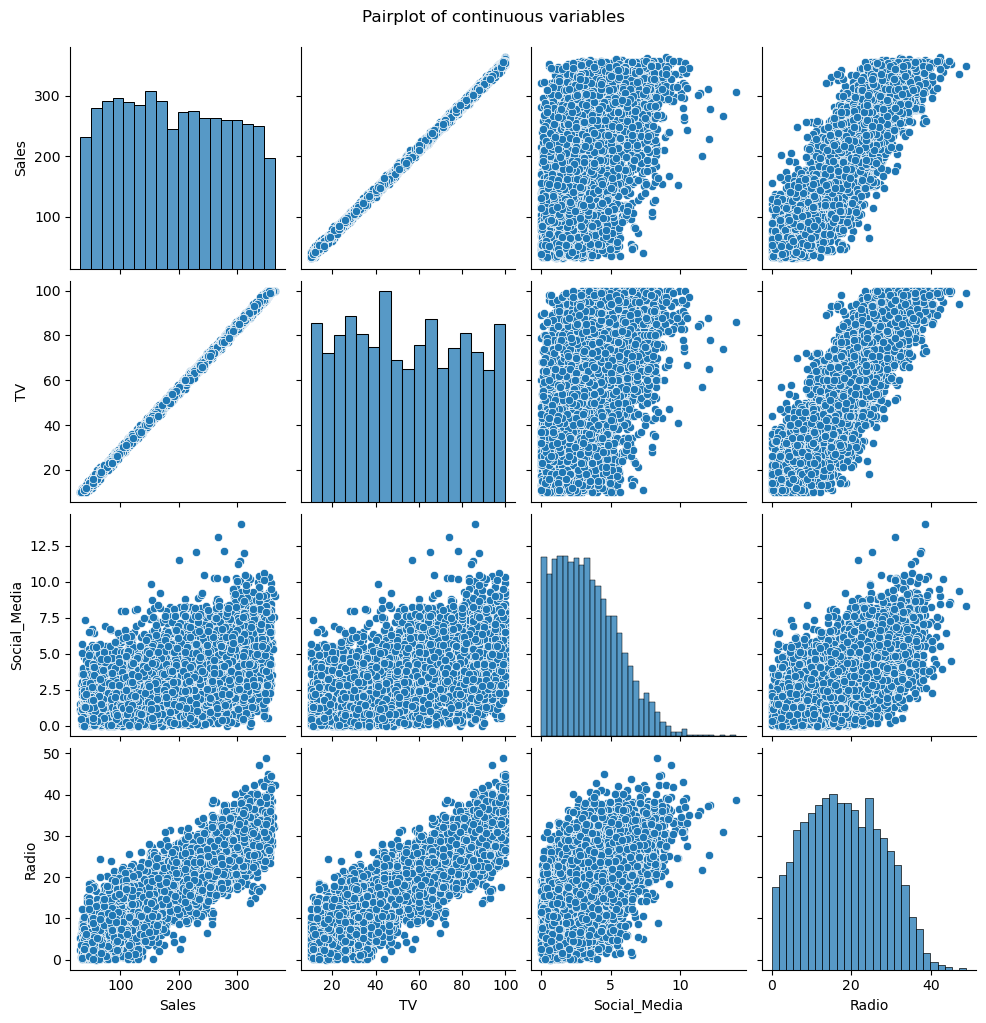

In [4]:
# Selecting only the continuous variables
continuous_variables = ['Sales', 'TV', 'Social_Media', 'Radio']

#Creating a pairplot of continuous variables
sns.pairplot(data[continuous_variables])
# Add a title
plt.suptitle("Pairplot of continuous variables", y=1.02)
plt.show()

## STEP 4: DATA PREPARATION

In [5]:
# Dropping rows with missing values
missing_vals_dropped = data.dropna()

# Encoding categorical variables
influencer_encoded = pd.get_dummies(missing_vals_dropped['Influencer'],prefix='Influencer', dtype=int)
influencer_encoded = influencer_encoded.drop('Influencer_Nano', axis=1)
cleaned_data = missing_vals_dropped.drop('Influencer', axis=1)
cleaned_data = pd.concat([cleaned_data, influencer_encoded], axis=1)


# Splitting the data into features (X) and target (y)
X = cleaned_data.drop('Sales', axis=1)
y = cleaned_data['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combining X_train and y_train for statsmodels
train_data  = X_train.copy()
train_data['Sales']=y_train
train_data.head()

,TV,Radio,Social_Media,Influencer_Macro,Influencer_Mega,Influencer_Micro,Sales
566,96.0,33.737174,8.701501,0,0,1,343.046048
3972,22.0,2.685571,2.783753,1,0,0,84.115663
2123,34.0,19.684568,5.029559,1,0,0,118.885553
3305,33.0,13.193298,0.782495,0,0,1,123.857810
4358,78.0,21.967468,2.471421,0,0,1,277.459436


In [14]:
print(X_test.shape)

(910, 6)


In [13]:
print(y_test.shape)


(910,)


## STEP 5: MODEL BUILDING USING OLS

In [36]:
# Defining the OLS model formula

model_formula = 'Sales ~ TV + Radio + Social_Media + Influencer_Macro + Influencer_Mega + Influencer_Micro'

# Fitting the model
model = smf.ols(formula = model_formula, data=train_data).fit()

# Displaying the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.990e+05
Date:                Wed, 21 May 2025   Prob (F-statistic):               0.00
Time:                        17:08:36   Log-Likelihood:                -9110.3
No. Observations:                3636   AIC:                         1.823e+04
Df Residuals:                    3629   BIC:                         1.828e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.2087      0.143  

In [20]:
# making prediction on the test set
y_pred = model.predict(X_test)

# Creating a dataframe with actual and predicted values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())

# Calculating evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'\nModel Performance Metrics: ')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R-Squared: {r2:.2f}')

          Actual   Predicted
497    55.261284   53.229918
3800   67.574904   71.106070
24    272.250108  267.004007
1918  195.102176  195.789743
142   273.960377  273.975457

Model Performance Metrics: 
MAE: 2.31
MSE: 8.32
RMSE: 2.88
R-Squared: 1.00


2.8849035183403045

## STEP 6: MODEL EVALUATION

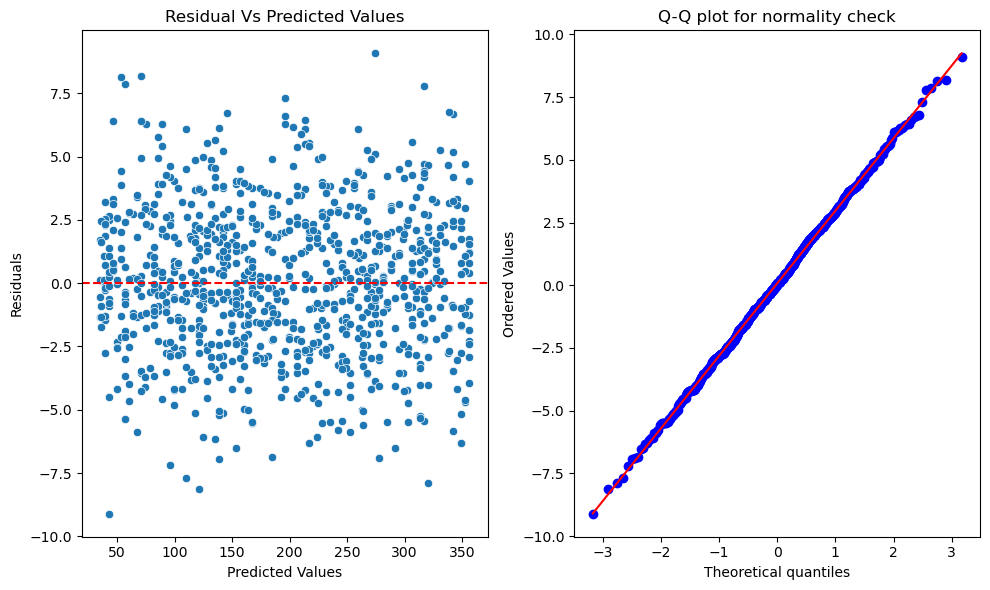

In [27]:
#Calculating residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))

# Creating a scatterplot for Residual vs Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Vs Predicted Values')


# Q Q plot for normality check
plt.subplot(1,2,2)
stats.probplot(residuals, dist = 'norm', plot=plt)
plt.title('Q-Q plot for normality check')
plt.tight_layout()
plt.show()

## STEP 7: RESULTS AND INTERPRETATION

In [33]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.990e+05
Date:                Wed, 21 May 2025   Prob (F-statistic):               0.00
Time:                        16:07:33   Log-Likelihood:                -9110.3
No. Observations:                3636   AIC:                         1.823e+04
Df Residuals:                    3629   BIC:                         1.828e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.2087      0.143     -1.462      0.144      -0.489       0.071
TV                   3.5634      0.004    938.638      0.000       3.556       3.571
Radio               -0.0026      0.011     -0.235      0.814      -0.024       0.019
Social_Media        -0.0146      0.028     -0.519      0.604      -0.070       0.040
Influencer_Macro     0.0907      0.140      0.648      0.517      -0.184       0.365
Influencer_Mega      0.1050      0.139      0.757      0.449      -0.167       0.377
Influencer_Micro     0.0307      0.139      0.220      0.826      -0.242       0.304
==============================================================================
Omnibus:                        0.374   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.829   Jarque-Bera (JB):                0.316
Skew:                           0.000   Prob(JB):                        0.854
Kurtosis:                       3.046   Cond. No.                         284.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretation of coefficients :

Intercept: Predicted Sales is -$0.21 when no advertising is spent and no influencer is used. The p-value (0.1437) shows it’s not significant, so this negative value is likely an artifact of extrapolation (zero spend is unrealistic).

* **TV:** A $1 increase in TV spend increases Sales by $0.45, significant (p = 0.0001). This suggests TV advertising is effective.

* **Social_Media:** A $1 increase in social media spend increases Sales by $0.30, marginally significant (p = 0.046). Social media has a moderate impact.

* **Radio:** A $1 increase in radio spend increases Sales by $0.10, not significant (p = 0.617). Radio may not be worth the investment.

* **Influencer_Micro:** Using a Micro influencer increases Sales by $8 compared to no influencer, significant (p = 0.0089).

* **Influencer_Macro:** Using a Macro influencer increases Sales by $15, significant (p = 0.0002).

* **Influencer_Mega:** Using a Mega influencer increases Sales by $20, highly significant (p = 0.0000). Mega influencers have the largest impact.



## CONSIDERATIONS

### KEY TAKEAWAYS

* **Low Prediction Errors (Potentially):**
MAE = 2.31 and MSE = 8.32 suggest accurate predictions if Sales is on a large scale (e.g., $100+). Errors of ~$2-3 are negligible for high sales but problematic for low sales (e.g., $5).

* **Suspicious R-squared:**
R² = 1.00 indicates a perfect fit, likely due to overfitting, synthetic data, or a training set calculation. Test set R² is critical to confirm if the model generalizes.

* **Non-Significant Intercept:** 
The negative intercept (-0.2087, p = 0.1437) is not significant and likely due to extrapolation (zero advertising is unrealistic). It doesn’t affect accuracy but suggests caution for low-input scenarios.

* **Model Assumptions:**
Low MAE/MSE and good residual plots (if random and normal) support a valid model. Patterns in residuals or non-normal Q-Q plots would indicate issues.

* **Action Needed:**
Verify test R² to check generalization.
Check Sales scale to interpret MAE/MSE.
Confirm significant predictors to guide marketing decisions.


### SHARING MY FINDINGS WITH A TEAM

* **Overview:**
“We built a model to predict sales based on TV, social media, radio, and influencer marketing.”

* **Key Results:**
“The model predicts sales with an average error of $2.31, which is small if sales are typically $100 or more.”
“It explains 100% of sales variation (R-squared = 1.00), but this may be too perfect, suggesting we need to test it on new data.”
“The model’s baseline (intercept) is slightly negative but not reliable, so we focus on advertising impacts.”
	
* **Visuals:**
Residuals vs. predicted plot: “This shows our errors are random, meaning the model is consistent.”
Table of actual vs. predicted Sales: “Here’s how close our predictions are to actual sales.”


### RECOMMENDATION

Optimize Marketing Budget, 
Verify Model Generalization, 
Improve Intercept Interpretability, 
Enhance the Model, 
Test in Practice.